# Introduction
## Spanish Version: 
Este notebook contiene el código utilizado en el articulo: "Design, synthesis and evaluation of biological activity of new analogues and derivatives of 4-nerolidylcatechol as potential fungicidal agents for the control of associated phytopathogens in cacao crops.". Concretamente, su enfoque se centra en la parte metodológica de procesamiento, entrenamiento y selección de modelos QSAR mediante aproximación de Free-Wilson. 

El presente notebook se separa en 3 partes. 

**Parte 1:** El objetivo es obtener la matriz de free wilson ajustada para cada tipo de bioactividad. Comienza con cargar el set de datos de las moléculas estudiadas (QSAR_Cristobal_Original_Dataset.tsv), filtrando por los análogos del nucleo nucleo 4 nerolidilcatecol (A1-A44). Dentro de estos análogos se pedira un input donde se ingresa el núcleo común estructural base para la posterior descomposición de R sustituyentes sobre este nucleo (En este caso corresponderá al smiles: "C1=CC=C(C=C1)C(=O)O", equivalente a un nucleo estructural base de ácido benzóico). Posteriormente realizará canonización de smiles sobre los sustituyentes aislados, generando una matriz de descomposición de R sustituyentes, que posteriormente mediante one hot encoding en pandas, obtendrá la matriz base de Free Wilson. En la cual, se recmoverán las filas con valores faltantes en la variable de actividad pIC50 respectiva, generando la matriz de Free Wilson de salida ajustada para fitopatógeno estudiado.

**Parte 2:** El objetivo es sobre cada tipo de matriz de Free-Wilson seleccionada, entrenar diferentes modelos de regresión para predecir bioactividad, y caracterizar impacto de sustituyentes en bioactividad. Para ello, se realizará partición en el set de datos entre 80:20 para entrenamiento y prueba usando la semilla aleatoria de 42. Se entrenará regresión lineal multiple ordinaria solo en el caso en que en el set de entrenamiento el número de muestras (n) sea mayor que el número de variables (p). Mientras que para todos los casos se entrenará regresión de ridge, regresión lasso, y regresión elastic net. En estos 3 ultimos se realizará optimización de hiperparámetros mediante grid search en un esquena de validación cruzada dejando uno afuera (LOOCV). 

**Parte 3:** El objetivo consiste en comparar y seleccionar los diferentes modelos de regresión para cada tipo de bioactividad. Empleando como métricas el R2, el MAE, y el RMSE en el set de prueba y el set de entrenamiento, así como graficar la relación entre las predicciones del modelo con los datos experimentales, y finalmente la obtención de las estimaciones de los coeficientes usando gráficos de tornado. 

## English Version: 

This notebook contains the code used in the article: "Design, synthesis and evaluation of biological activity of new analogues and derivatives of 4-nerolidylcatechol as potential fungal agents for the control of associated pathogens in cacao crops.". Specifically, its focus is on the methodological part of processing, training and selection of QSAR models using the Free-Wilson approach. 

This notebook is separated into 3 parts. 

**Part 1:** The objective is to obtain the free wilson matrix adjusted for each type of bioactivity. It begins by loading the data set of the molecules studied (QSAR_Cristobal_Original_Dataset.tsv), filtering by the nucleo analogues nucleus 4 nerolidylcatechol (A1-A44). Within these analogues, an input will be requested where the base structural common nucleus is entered for the subsequent decomposition of R substituents on this nucleus (In this case it will correspond to the smiles: "C1=CC=C(C=C1)C(=O)O ", equivalent to a benzoic acid base structural nucleus). Subsequently, it will canonize smiles on the isolated substituents, generating a decomposition matrix of R substituents, which subsequently, through one hot encoding in pandas, will obtain the Free Wilson base matrix. In which, the rows with missing values in the respective pIC50 activity variable will be moved, generating the Free Wilson matrix of adjusted output for the phytopathogen studied. 

**Part 2:** The objective is on each type of Free-Wilson matrix selected, to train different regression models to predict bioactivity, and characterize the impact of substituents on bioactivity. To do this, the data set will be partitioned between 80:20 for training and testing using the random seed of 42. Ordinary multiple linear regression will be trained only in the case where in the training set the number of samples (n) is greater than the number of variables (p). While for all cases ridge regression, lasso regression, and elastic net regression will be trained. In these last 3, hyperparameter optimization will be carried out using grid search in a cross-validation corner, leaving one out (LOOCV). 

**Part 3:** The objective is to compare and select the different regression models for each type of bioactivity. Using R2, MAE, and RMSE as metrics in the test set and the training set, as well as graphing the relationship between the model predictions with the experimental data, and finally obtaining the coefficient estimates using graphs tornado.


# 1. Generación de matriz de free wilson

## 1.1 Cargar y preprocesar datos (Crear matriz de free wilson como variables dummy con codificación one-hot)

In [7]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.rdRGroupDecomposition import RGroupDecompose


############################################################
# CANONICALIZAR SUSTITUYENTES
############################################################

def canonicalize_rgroup(smiles):

    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return smiles

    return Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=False
    )


def main():

    ########################################################
    # INPUT CORE
    ########################################################

    core_smiles = input(
        "\nIngrese el SMILES del núcleo común: "
    ).strip()

    core = Chem.MolFromSmiles(
        core_smiles
    )

    if core is None:
        raise ValueError(
            "No se pudo interpretar el SMILES del núcleo."
        )

    ########################################################
    # DATA
    ########################################################

    df = pd.read_csv(
        "QSAR_Cristobal_Original_Dataset.tsv",
        sep="\t"
    )

    df = df.iloc[10:].reset_index(
        drop=True
    )

    print(
        "\nMoléculas leídas:",
        len(df)
    )

    ########################################################
    # SMILES -> MOL
    ########################################################

    df["mol"] = df["SMILES"].apply(
        Chem.MolFromSmiles
    )

    df = df[
        df["mol"].notnull()
    ].reset_index(
        drop=True
    )

    print(
        "Moléculas válidas:",
        len(df)
    )

    ########################################################
    # RGROUP DECOMPOSITION
    ########################################################

    print(
        "\nEjecutando RGroupDecompose..."
    )

    groups, unmatched = RGroupDecompose(
        [core],
        df["mol"].tolist(),
        asSmiles=True
    )

    print(
        "Moléculas asignadas:",
        len(groups)
    )

    print(
        "Moléculas no asignadas:",
        len(unmatched)
    )

    ########################################################
    # CONSERVAR SOLO MATCHES
    ########################################################

    if len(unmatched) > 0:

        matched_idx = [
            i
            for i in range(len(df))
            if i not in unmatched
        ]

        df = df.iloc[
            matched_idx
        ].reset_index(
            drop=True
        )

    ########################################################
    # RGROUP DATAFRAME
    ########################################################

    rgroup_df = pd.DataFrame(
        groups
    )

    ########################################################
    # CANONICALIZAR TODOS LOS RGROUPS
    ########################################################

    for col in rgroup_df.columns:

        if col == "Core":
            continue

        rgroup_df[col] = rgroup_df[col].apply(
            canonicalize_rgroup
        )

    print(
        "\nColumnas encontradas:"
    )

    print(
        rgroup_df.columns.tolist()
    )

    ########################################################
    # GUARDAR DESCOMPOSICIÓN
    ########################################################

    rgroup_df.to_csv(
        "rgroup_decomposition.tsv",
        sep="\t",
        index=False
    )

    ########################################################
    # COLUMNAS R
    ########################################################

    r_cols = [
        c
        for c in rgroup_df.columns
        if c != "Core"
    ]

    if len(r_cols) == 0:

        raise ValueError(
            "No se detectaron grupos R."
        )

    ########################################################
    # PREPARAR RGROUPS
    ########################################################

    X_rgroups = rgroup_df[
        r_cols
    ].copy()

    X_rgroups = X_rgroups.fillna(
        "None"
    )

    ########################################################
    # MATRIZ FREE-WILSON
    ########################################################

    free_wilson_df = pd.DataFrame(
        index=X_rgroups.index
    )

    ########################################################
    # VARIABLES BINARIAS
    ########################################################

    for rcol in r_cols:

        unique_values = sorted(
            X_rgroups[rcol].unique()
        )

        for value in unique_values:

            column_name = (
                f"{rcol}_{value}"
            )

            free_wilson_df[
                column_name
            ] = (
                X_rgroups[rcol]
                .eq(value)
                .astype(int)
            )

    ########################################################
    # AGREGAR INFORMACIÓN
    ########################################################

    free_wilson_df.insert(
        0,
        "SMILES",
        df["SMILES"].values
    )
    print(f"Columnas disponibles: {df.columns}")
    valor_d = input("Poner nombre de columna de actividad: ") 
    if valor_d in df.columns:

        free_wilson_df.insert(
            1,
            "Actividad",
            df[
                valor_d
            ].values
        )
        
        # ELIMINAR FILAS QUE TENGAN NA EN LA COLUMNA DE ACTIVIDAD
        free_wilson_df = free_wilson_df.dropna(subset=["Actividad"]).reset_index(
            drop=True
        )

    ########################################################
    # INFO
    ########################################################

    print("\n" + "=" * 60)

    print(
        "MATRIZ FREE-WILSON"
    )

    print("=" * 60)

    print(
        "Filas:",
        free_wilson_df.shape[0]
    )

    print(
        "Columnas:",
        free_wilson_df.shape[1]
    )

    print(
        "\nPrimeras variables:"
    )

    print(
        free_wilson_df.columns[
            :20
        ].tolist()
    )

    ########################################################
    # GUARDAR MATRIZ
    ########################################################

    free_wilson_df.to_csv(
        "free_wilson_matrix.tsv",
        sep="\t",
        index=False
    )

    print(
        "\nArchivos generados:"
    )

    print(
        " - rgroup_decomposition.tsv"
    )

    print(
        " - free_wilson_matrix.tsv"
    )


if __name__ == "__main__":
    main()


Ingrese el SMILES del núcleo común:  C1=CC=C(C=C1)C(=O)O



Moléculas leídas: 44
Moléculas válidas: 44

Ejecutando RGroupDecompose...
Moléculas asignadas: 44
Moléculas no asignadas: 0

Columnas encontradas:
['Core', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6']
Columnas disponibles: Index(['NOMBRE', 'SMILES', 'M_roreri', 'L_theobromae', 'Phytophthora_sp',
       'MASA_MOLAR', 'Valor_D_M_roreri', 'Valor_D_L_theobromae',
       'Valor_D_Phytophthora_sp', 'IC_50_M_roreri', 'IC_50_L_theobromae',
       'IC_50_Phytophthora_sp', 'pIC_50_M_roreri', 'pIC_50_L_theobromae',
       'pIC_50_Phytophthora_sp', 'mol'],
      dtype='str')


[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with dummy atom neighbors
[13:41:06] WARNING: not removing hydrogen atom with

Poner nombre de columna de actividad:  pIC_50_Phytophthora_sp



MATRIZ FREE-WILSON
Filas: 34
Columnas: 20

Primeras variables:
['SMILES', 'Actividad', 'R1_CC(C)=CCCC(C)=CCCC(C)=CC[*:1]', 'R1_CC(C)=CCCC(C)=CC[*:1]', 'R1_CC(C)=CC[*:1]', 'R1_CCCC[*:1]', 'R2_O[*:2]', 'R2_[H][*:2]', 'R3_O[*:3]', 'R3_[H][*:3]', 'R4_O[*:4]', 'R4_[H][*:4]', 'R5_C(O[*:5])O[*:6]', 'R5_CO[*:5]', 'R5_O[*:5]', 'R5_[H][*:5]', 'R6_C(O[*:5])O[*:6]', 'R6_CO[*:6]', 'R6_O[*:6]', 'R6_[H][*:6]']

Archivos generados:
 - rgroup_decomposition.tsv
 - free_wilson_matrix.tsv


# 2. Regresión lineal,lasso, ridge, elastic net

Dimensiones de la matriz original: (34, 18)

Iniciando optimización exhaustiva de modelos...


Evaluando Modelos:  25%|████████████████▊                                                  | 1/4 [00:00<00:00,  6.87it/s]

 -> Lineal_Simple ajustado (Sin hiperparámetros).


Evaluando Modelos:  50%|█████████████████████████████████▌                                 | 2/4 [00:52<01:01, 30.63s/it]

 -> Mejor Ridge Alpha (λ): 1.05956


Evaluando Modelos:  75%|██████████████████████████████████████████████████▎                | 3/4 [01:20<00:29, 29.56s/it]

 -> Mejor Lasso Alpha (λ): 0.00450


Evaluando Modelos: 100%|███████████████████████████████████████████████████████████████████| 4/4 [02:10<00:00, 32.65s/it]

 -> Mejor ElasticNet: Alpha=0.00518, l1_ratio=0.9

              REPORTE DIAGNÓSTICO COMPLETO DE RENDIMIENTO
[LINEAL_SIMPLE]
  Entrenamiento (Train):
    R²:  0.732 | R² Adj:  0.128 | RMSE: 0.111 | MAE: 0.084
    Error Máx: 0.293 | Desv. Est. Residuos: 0.111
  Validación (Test):
    R²:  0.701 | RMSE: 0.099 | MAE: 0.083
    Error Máx: 0.178
-------------------------------------------------------------------------------------
[RIDGE]
  Entrenamiento (Train):
    R²:  0.705 | R² Adj:  0.042 | RMSE: 0.116 | MAE: 0.080
    Error Máx: 0.385 | Desv. Est. Residuos: 0.116
  Validación (Test):
    R²:  0.687 | RMSE: 0.101 | MAE: 0.075
    Error Máx: 0.180
-------------------------------------------------------------------------------------
[LASSO]
  Entrenamiento (Train):
    R²:  0.711 | R² Adj:  0.060 | RMSE: 0.115 | MAE: 0.079
    Error Máx: 0.370 | Desv. Est. Residuos: 0.115
  Validación (Test):
    R²:  0.624 | RMSE: 0.110 | MAE: 0.082
    Error Máx: 0.202
---------------------------------

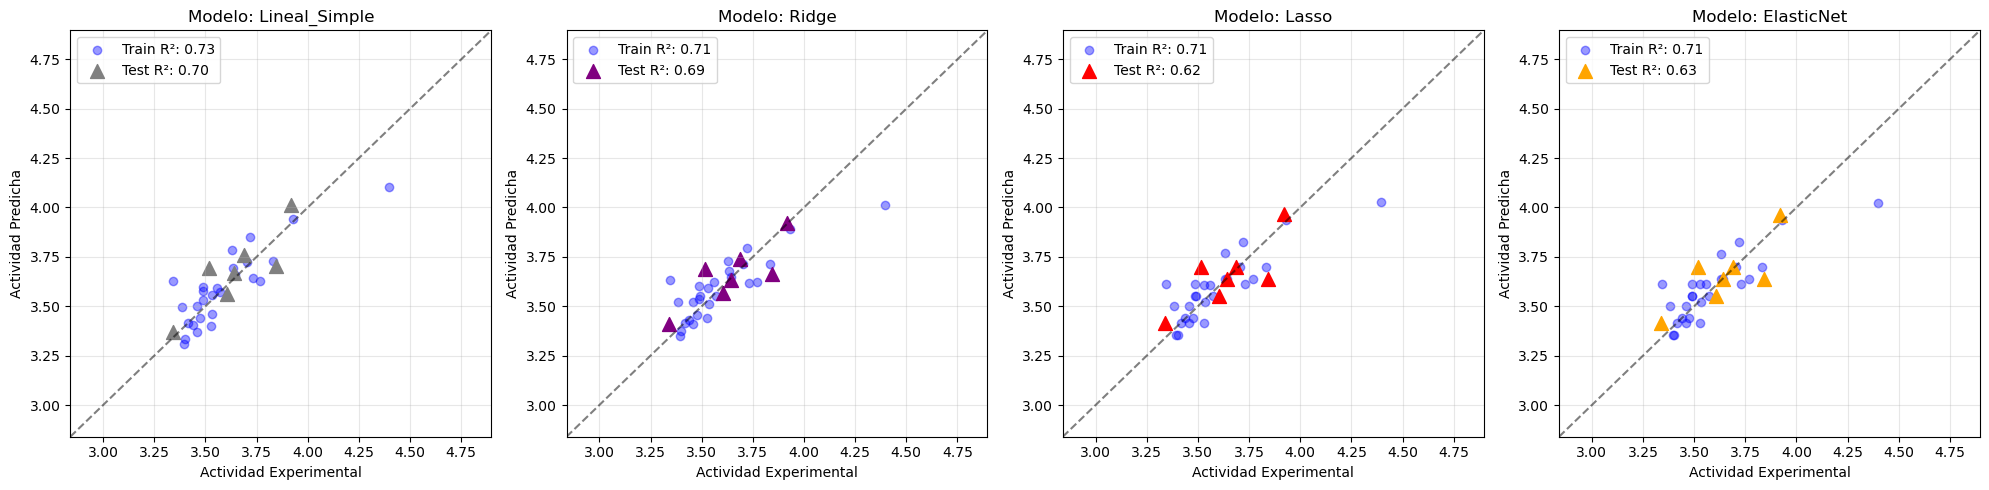


Generando Tornado Plots de coeficientes...


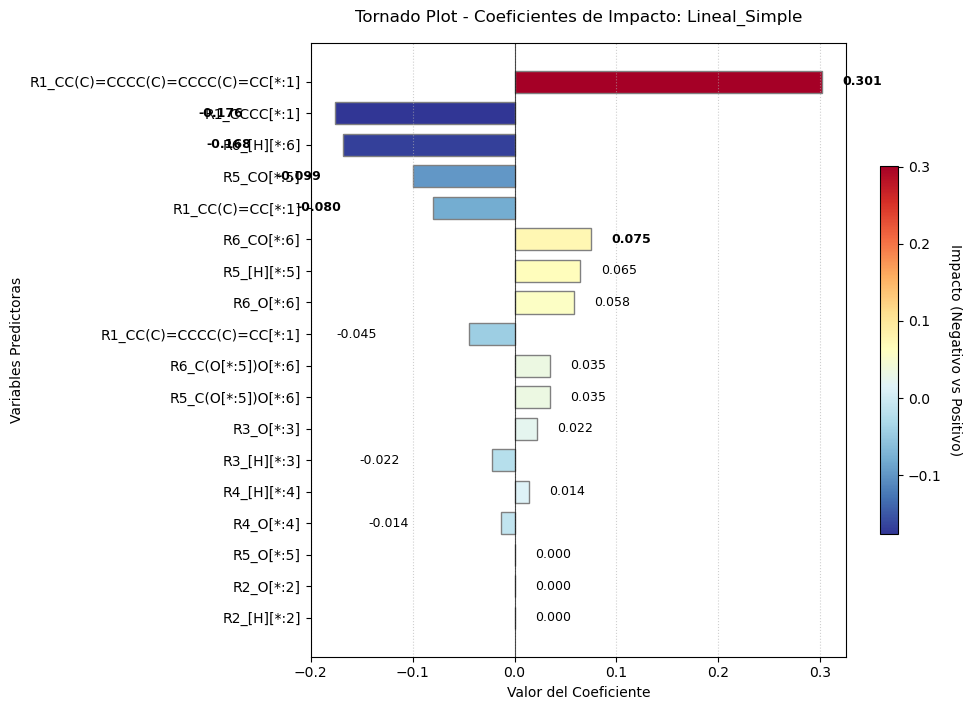

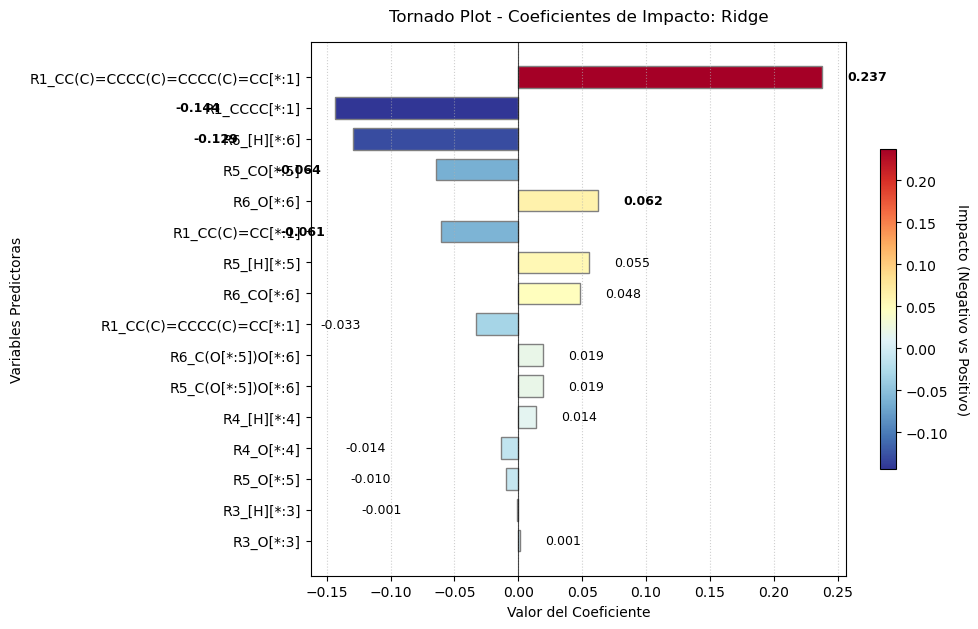

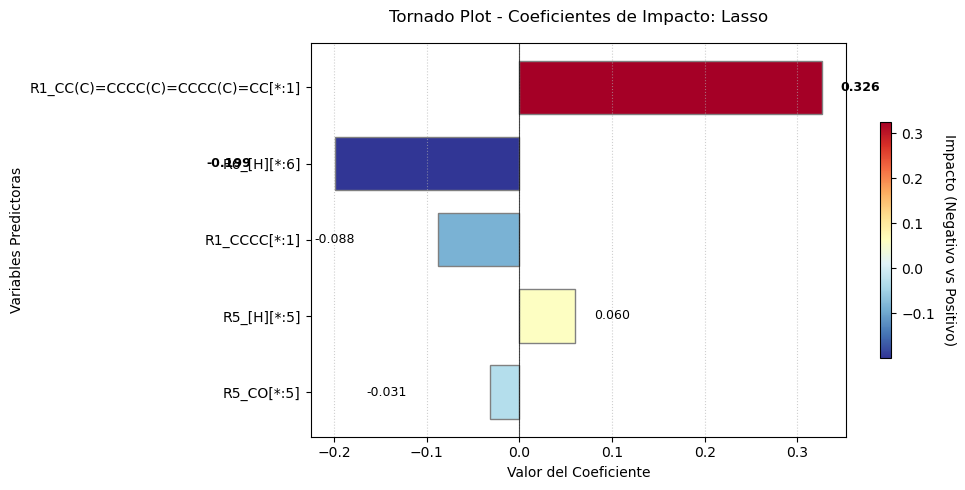

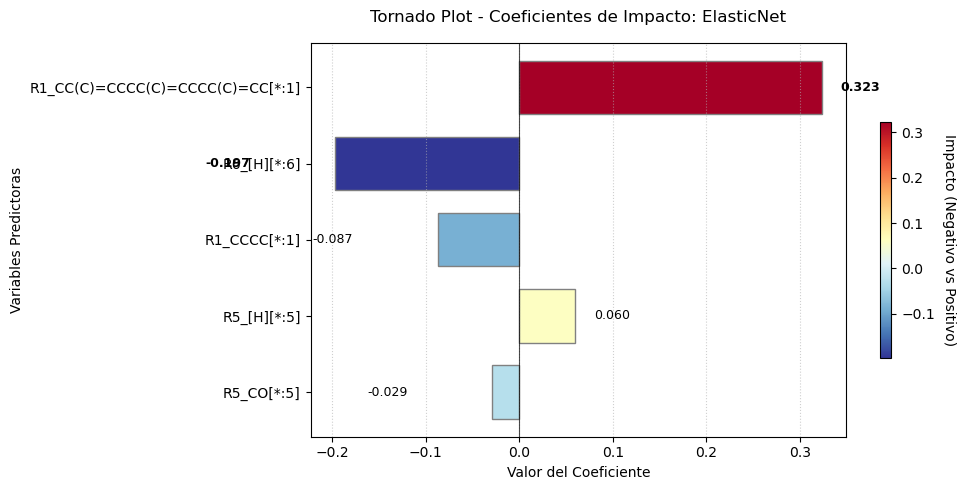

In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, LeaveOneOut, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("free_wilson_matrix.tsv", sep="\t")

# ============================================================
# 1. Seleccionar variables originales
# ============================================================
y = df["Actividad"]
X = df.iloc[:, 2:]  # Todas las columnas después de Actividad
X = X.astype(float)
feature_names = X.columns.tolist()

print(f"Dimensiones de la matriz original: {X.shape}")

# ============================================================
# 2. Train-Test Split (Mantenemos la misma semilla reproducible)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

loo = LeaveOneOut()

# ============================================================
# 3. Definición de Grillas Exhaustivas para Hiperparámetros
# ============================================================
alphas_dense = np.logspace(-5, 3, 200)

param_grid_en = {
    'alpha': np.logspace(-4, 2, 50),
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
}

# Diccionario con configuraciones base de los modelos (Añadido OLS)
modelos_config = {
    "Lineal_Simple": {
        "estimator": LinearRegression(),
        "params": {}  # Sin hiperparámetros que optimizar
    },
    "Ridge": {
        "estimator": Ridge(random_state=42),
        "params": {'alpha': alphas_dense}
    },
    "Lasso": {
        "estimator": Lasso(max_iter=20000, random_state=42),
        "params": {'alpha': alphas_dense}
    },
    "ElasticNet": {
        "estimator": ElasticNet(max_iter=20000, random_state=42),
        "params": param_grid_en
    }
}

# ============================================================
# 4. GridSearch Exhaustivo con Seguimiento tqdm
# ============================================================
modelos_optimos = {}
print("\nIniciando optimización exhaustiva de modelos...")

for nombre_modelo, config in tqdm(modelos_config.items(), desc="Evaluando Modelos"):
    
    # Si no hay parámetros (caso OLS LinearRegression), no requiere búsqueda densa cross-val
    if not config["params"]:
        model = config["estimator"]
        model.fit(X_train, y_train)
        modelos_optimos[nombre_modelo] = model
        print(f" -> {nombre_modelo} ajustado (Sin hiperparámetros).")
    else:
        grid_search = GridSearchCV(
            estimator=config["estimator"],
            param_grid=config["params"],
            cv=loo,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        grid_search.fit(X_train, y_train)
        modelos_optimos[nombre_modelo] = grid_search.best_estimator_
        
        if nombre_modelo != "ElasticNet":
            print(f" -> Mejor {nombre_modelo} Alpha (λ): {grid_search.best_params_['alpha']:.5f}")
        else:
            print(f" -> Mejor ElasticNet: Alpha={grid_search.best_params_['alpha']:.5f}, l1_ratio={grid_search.best_params_['l1_ratio']}")

# 3. Resultados


              REPORTE DIAGNÓSTICO COMPLETO DE RENDIMIENTO
[LINEAL_SIMPLE]
  Entrenamiento (Train):
    R²:  0.732 | R² Adj:  0.128 | RMSE: 0.111 | MAE: 0.084
    Error Máx: 0.293 | Desv. Est. Residuos: 0.111
  Validación (Test):
    R²:  0.701 | RMSE: 0.099 | MAE: 0.083
    Error Máx: 0.178
-------------------------------------------------------------------------------------
[RIDGE]
  Entrenamiento (Train):
    R²:  0.705 | R² Adj:  0.042 | RMSE: 0.116 | MAE: 0.080
    Error Máx: 0.385 | Desv. Est. Residuos: 0.116
  Validación (Test):
    R²:  0.687 | RMSE: 0.101 | MAE: 0.075
    Error Máx: 0.180
-------------------------------------------------------------------------------------
[LASSO]
  Entrenamiento (Train):
    R²:  0.711 | R² Adj:  0.060 | RMSE: 0.115 | MAE: 0.079
    Error Máx: 0.370 | Desv. Est. Residuos: 0.115
  Validación (Test):
    R²:  0.624 | RMSE: 0.110 | MAE: 0.082
    Error Máx: 0.202
-----------------------------------------------------------------------------------

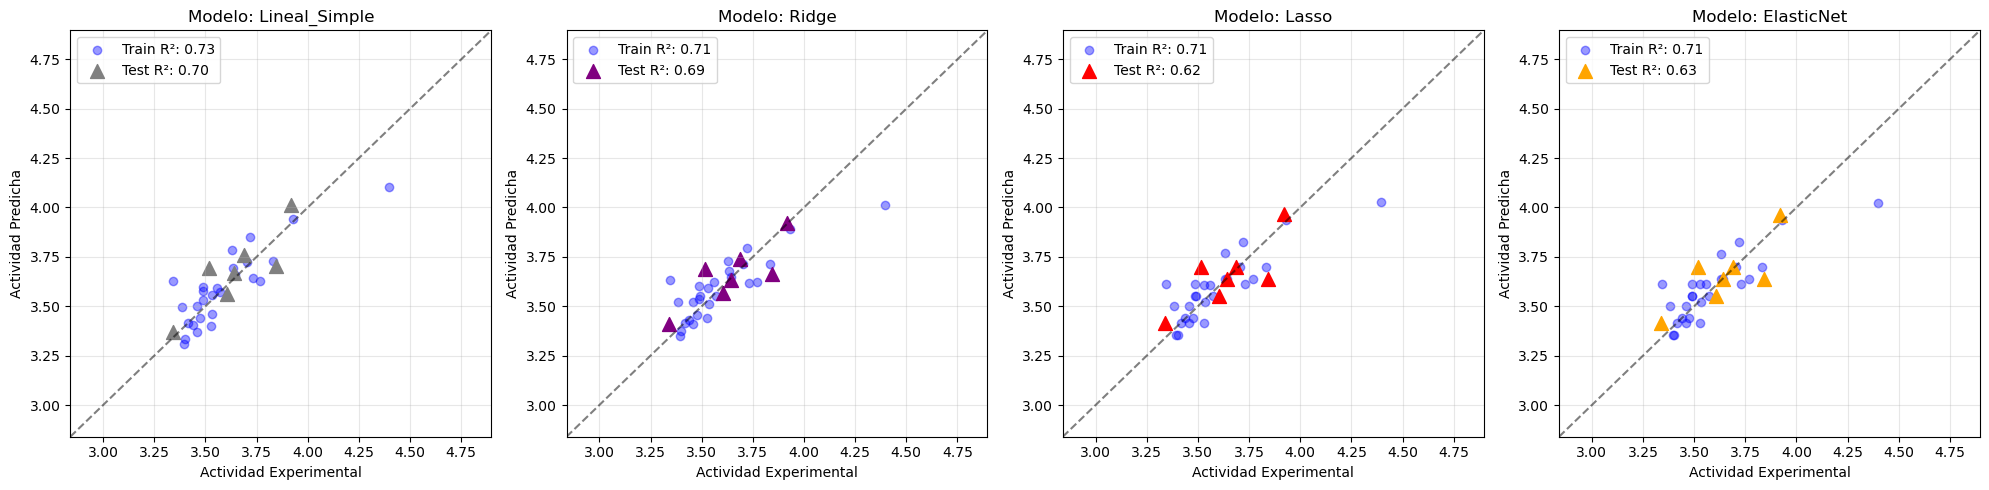


Generando Tornado Plots de coeficientes...


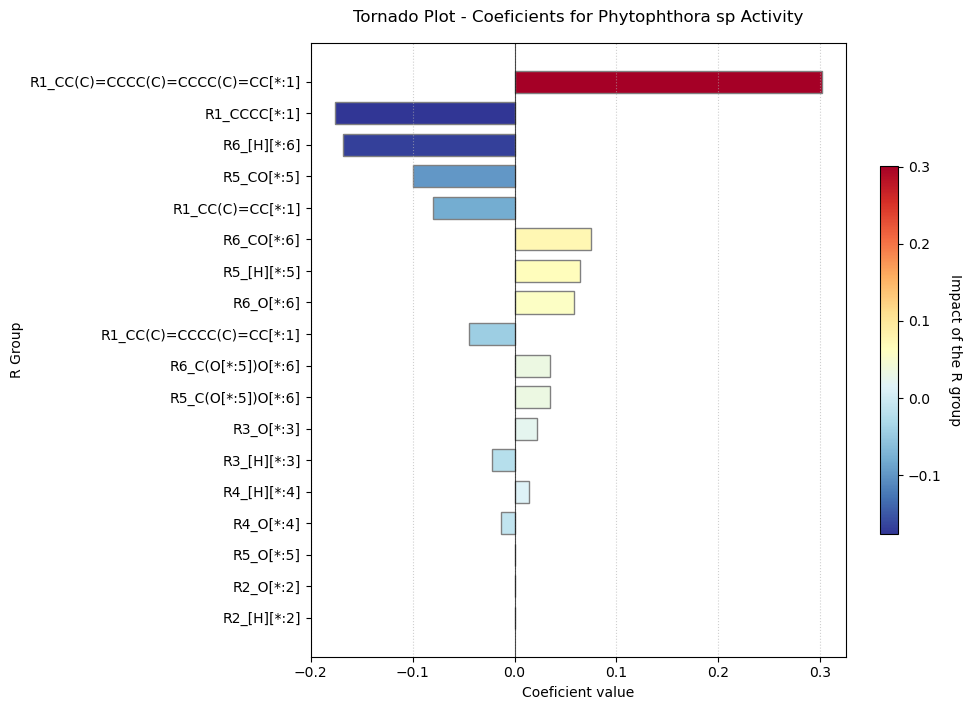

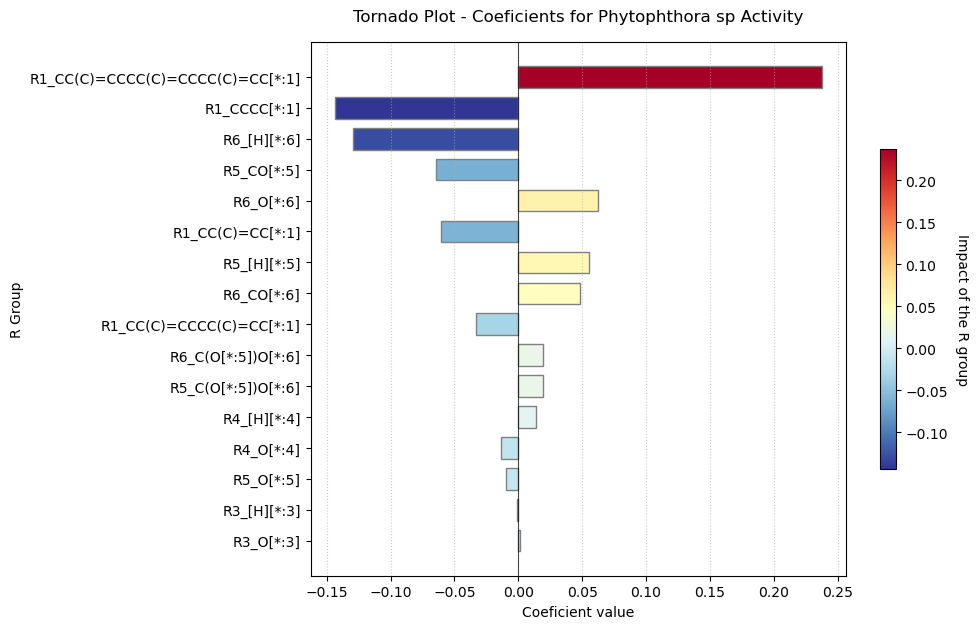

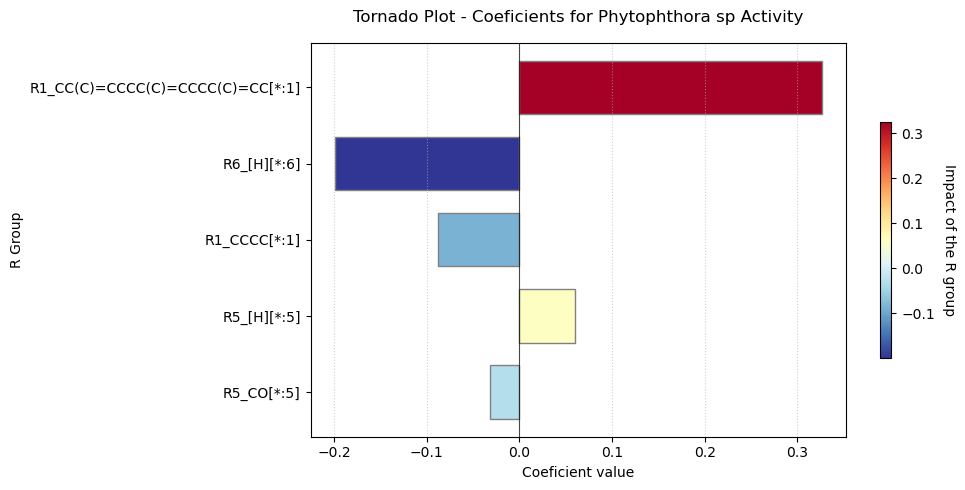

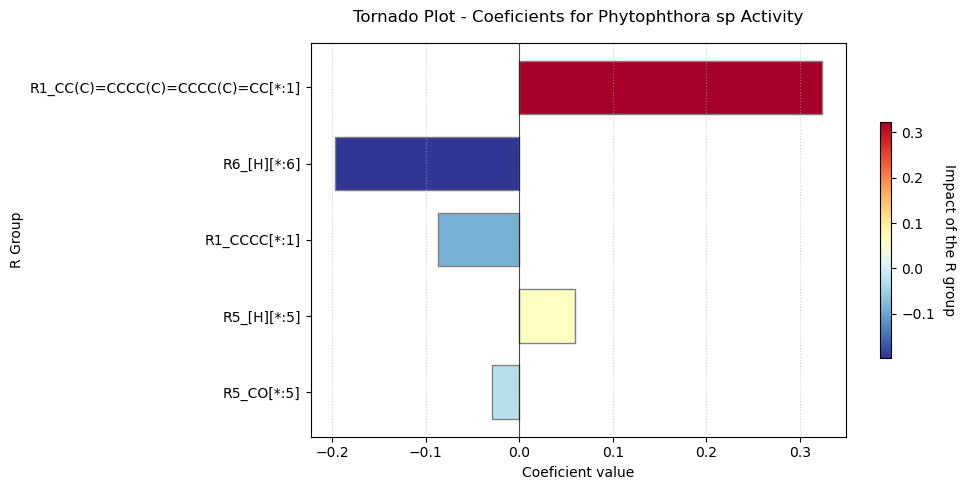

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
# ============================================================
# 5. Evaluación de Predicciones y Métricas de Diagnóstico
# ============================================================
def obtener_metricas_extendidas(y_real, y_pred, n_features):
    r2 = r2_score(y_real, y_pred)
    n = len(y_real)
    # R2 Ajustado
    r2_adj = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1)) if (n - n_features - 1) > 0 else np.nan
    
    residuos = y_real - y_pred
    std_residuos = np.std(residuos)
    
    return {
        "R2": r2,
        "R2_Adj": r2_adj,
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "Max_Error": np.max(np.abs(residuos)),
        "Std_Residuos": std_residuos
    }

resultados = {}
for nombre, modelo in modelos_optimos.items():
    pred_tr = modelo.predict(X_train)
    pred_te = modelo.predict(X_test)
    resultados[nombre] = {
        "train": obtener_metricas_extendidas(y_train, pred_tr, X_train.shape[1]),
        "test": obtener_metricas_extendidas(y_test, pred_te, X_test.shape[1]),
        "pred_tr": pred_tr,
        "pred_te": pred_te
    }

# Imprimir Reporte de Diagnóstico Completo
print("\n" + "="*85)
print("              REPORTE DIAGNÓSTICO COMPLETO DE RENDIMIENTO")
print("="*85)
for mod in modelos_config.keys():
    res = resultados[mod]
    print(f"[{mod.upper()}]")
    print(f"  Entrenamiento (Train):")
    print(f"    R²: {res['train']['R2']:6.3f} | R² Adj: {res['train']['R2_Adj']:6.3f} | RMSE: {res['train']['RMSE']:.3f} | MAE: {res['train']['MAE']:.3f}")
    print(f"    Error Máx: {res['train']['Max_Error']:.3f} | Desv. Est. Residuos: {res['train']['Std_Residuos']:.3f}")
    print(f"  Validación (Test):")
    print(f"    R²: {res['test']['R2']:6.3f} | RMSE: {res['test']['RMSE']:.3f} | MAE: {res['test']['MAE']:.3f}")
    print(f"    Error Máx: {res['test']['Max_Error']:.3f}")
    print("-" * 85)

# ============================================================
# 6. Gráficos Comparativos Simultáneos (Observado vs Predicho)
# ============================================================
plt.figure(figsize=(20, 5))
colores = {"Lineal_Simple": "gray", "Ridge": "purple", "Lasso": "red", "ElasticNet": "orange"}
lims = [min(y)-0.5, max(y)+0.5]

for idx, nombre in enumerate(modelos_config.keys(), start=1):
    plt.subplot(1, 4, idx)
    res = resultados[nombre]
    
    plt.scatter(y_train, res["pred_tr"], color="blue", alpha=0.4, label=f"Train R²: {res['train']['R2']:.2f}")
    plt.scatter(y_test, res["pred_te"], color=colores[nombre], marker="^", s=100, label=f"Test R²: {res['test']['R2']:.2f}")
    
    plt.plot(lims, lims, '--', color="black", alpha=0.5)
    plt.title(f"Modelo: {nombre}")
    plt.xlabel("Actividad Experimental")
    plt.ylabel("Actividad Predicha")
    plt.xlim(lims)
    plt.ylim(lims)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Comparativa_Modelos_Extendida.png", dpi=300)
plt.show()

# ============================================================
# 7. Generación de Tornado Plots para Coeficientes
# ============================================================
print("\nGenerando Tornado Plots de coeficientes...")

for nombre, modelo in modelos_optimos.items():
    coefs = modelo.coef_
    
    # Crear un DataFrame con los nombres de variables y sus coeficientes
    df_coefs = pd.DataFrame({
        'Variable': feature_names,
        'Coeficiente': coefs,
        'Magnitud': np.abs(coefs)
    })
    
    # Ordenar por el impacto absoluto para el efecto visual de "Tornado"
    df_coefs = df_coefs.sort_values(by='Magnitud', ascending=True)
    
    # Omitir variables cuyo coeficiente sea exactamente 0 (muy común en Lasso/ElasticNet)
    df_coefs_filtrados = df_coefs[df_coefs['Coeficiente'] != 0]
    
    if df_coefs_filtrados.empty:
        print(f"El modelo {nombre} penalizó todos los coeficientes a cero. Se omite su gráfico.")
        continue

    plt.figure(figsize=(10, max(5, len(df_coefs_filtrados) * 0.4)))
    
    # Crear paleta de gradientes basada en el valor real del coeficiente (Divergente: de negativo a positivo)
    norm = plt.Normalize(df_coefs_filtrados['Coeficiente'].min(), df_coefs_filtrados['Coeficiente'].max())
    sm = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=norm)
    colores_barras = [sm.to_rgba(c) for c in df_coefs_filtrados['Coeficiente']]
    
    # Graficar barras horizontales
    bars = plt.barh(df_coefs_filtrados['Variable'], df_coefs_filtrados['Coeficiente'], color=colores_barras, edgecolor='grey', height=0.7)
    
    # Línea central de referencia en cero
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

    plt.title(f"Tornado Plot - Coeficients for Phytophthora sp Activity", fontsize=12, pad=15)
    plt.xlabel("Coeficient value")
    plt.ylabel("R Group")
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)
    
    # Añadir barra de color explicativa al costado
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.6)
    cbar.set_label('Impact of the R group', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.savefig(f"Tornado_Plot_{nombre}.png", dpi=300)
    plt.show()